# FASE 1: Exploración del dataset agroclimático

### Santiago Mosquera y Samuel Rengifo


**Proyecto:** Sistema de monitoreo de sensores IoT y analítica de datos agroclimáticos para agricultura digital  
**Cultivos analizados:** Caña de azúcar (Valle del Cauca) y Arroz (Tolima, Casanare, Meta)  
**Curso:** Sistemas y Comunicaciones I — Universidad ICESI  
**Fase:** 1 — Exploración del dataset agroclimático


---

## Objetivo

Comprender la estructura y el potencial analítico de un dataset agroclimático real con más de 50.000 registros, identificar las variables más relevantes para el análisis del comportamiento de los cultivos de **caña de azúcar** y **arroz** en Colombia, y evaluar la calidad de los datos para soportar las fases posteriores del proyecto.

## Fuente de datos: NASA POWER + corrección por elevación

Se utiliza **NASA POWER** (Prediction Of Worldwide Energy Resources) como única fuente externa de datos. Esta API agroclimatológica de la NASA se basa en el reanálisis MERRA-2 y proporciona series diarias gratuitas, sin autenticación, para cualquier coordenada del planeta.

**Problema conocido en zonas montañosas:**

MERRA-2 tiene resolución espacial de aproximadamente 0,5° × 0,625° (~50 km).

Para el Valle del Cauca, esa celda de grilla **promedia el valle plano (~1.000 m s.n.m.) con la cordillera Central y Occidental (>3.000 m)**, lo que genera un **sesgo frío sistemático** en la temperatura del aire de unos **-7 °C** respecto a la realidad del valle.

**Solución implementada:** una función Python que corrige las temperaturas crudas de NASA POWER usando el **lapse rate atmosférico estándar** (6,5 °C por km de altura), anclando el cálculo a una temperatura de referencia conocida y validada por IDEAM y Cenicaña: **24 °C a 1.000 m s.n.m.** (Palmira).

Para cada zona se calcula:

1. **Temperatura esperada** a su elevación real:  
   `T_esperada = 24 − 6,5 × (elev_real − 1.000) / 1.000`
2. **Factor de corrección**:  
   `ΔT = T_esperada − T_NASA_promedio`
3. Se suma `ΔT` a todas las temperaturas diarias (T2M, T2M_MAX, T2M_MIN), preservando la variabilidad estacional y la amplitud térmica diaria — solo se ajusta el nivel medio.

## Ubicaciones de estudio (8 zonas reales)

- **Caña**: Palmira, Candelaria, Tuluá, Caicedonia (Valle del Cauca)
- **Arroz**: El Espinal, Saldaña (Tolima — riego), Yopal (Casanare — secano), Villavicencio (Meta)

---
## 1. Carga del dataset

In [ ]:
# Importación de librerías
import os
import io
import json
import time
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import requests

# Plotly es opcional: si no está instalado, el notebook continúa con matplotlib/seaborn
try:
    import plotly.express as px
    import plotly.graph_objects as go
    PLOTLY_OK = True
except ImportError:
    PLOTLY_OK = False
    print('Plotly no disponible — se usarán matplotlib y seaborn.')

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams.update({
    'figure.dpi': 100,
    'figure.figsize': (12, 5),
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans'
})
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


In [ ]:
# === Definición de las 8 zonas de estudio en Colombia ===
# Coordenadas y altitudes reales según IGAC e IDEAM. La altitud es la pieza
# clave para la corrección del sesgo de NASA POWER (lapse rate atmosférico).
ZONAS_COLOMBIA = [
    {'ubicacion': 'Palmira_VAC',       'cultivo': 'caña_de_azúcar', 'departamento': 'Valle del Cauca', 'lat': 3.51, 'lon': -76.31, 'altitud_m': 1001},
    {'ubicacion': 'Candelaria_VAC',    'cultivo': 'caña_de_azúcar', 'departamento': 'Valle del Cauca', 'lat': 3.41, 'lon': -76.34, 'altitud_m': 980},
    {'ubicacion': 'Tulua_VAC',         'cultivo': 'caña_de_azúcar', 'departamento': 'Valle del Cauca', 'lat': 4.09, 'lon': -76.19, 'altitud_m': 970},
    {'ubicacion': 'Caicedonia_VAC',    'cultivo': 'caña_de_azúcar', 'departamento': 'Valle del Cauca', 'lat': 4.33, 'lon': -75.83, 'altitud_m': 1100},
    {'ubicacion': 'Espinal_TOL',       'cultivo': 'arroz',          'departamento': 'Tolima',          'lat': 4.15, 'lon': -74.88, 'altitud_m': 323},
    {'ubicacion': 'Saldana_TOL',       'cultivo': 'arroz',          'departamento': 'Tolima',          'lat': 3.93, 'lon': -75.02, 'altitud_m': 326},
    {'ubicacion': 'Yopal_CAS',         'cultivo': 'arroz',          'departamento': 'Casanare',        'lat': 5.34, 'lon': -72.40, 'altitud_m': 350},
    {'ubicacion': 'Villavicencio_MET', 'cultivo': 'arroz',          'departamento': 'Meta',            'lat': 4.14, 'lon': -73.62, 'altitud_m': 467},
]

# Rangos de temperatura media diaria esperados por IDEAM / Cenicaña / FEDEARROZ
# (informativos — no se usan para descartar datos, solo para reportar)
RANGOS_TEMP_ESPERADOS = {
    'Palmira_VAC':       (22.5, 26.0),
    'Candelaria_VAC':    (22.5, 26.0),
    'Tulua_VAC':         (22.0, 25.5),
    'Caicedonia_VAC':    (21.0, 24.5),
    'Espinal_TOL':       (25.5, 29.5),
    'Saldana_TOL':       (25.5, 29.5),
    'Yopal_CAS':         (25.0, 28.5),
    'Villavicencio_MET': (24.5, 28.0),
}

FECHA_INICIO = '2007-01-01'
FECHA_FIN    = '2024-12-31'

print(f'Zonas a consultar: {len(ZONAS_COLOMBIA)}')
print(f'Periodo: {FECHA_INICIO} a {FECHA_FIN}')
print('Rangos esperados de temperatura media diaria (°C) — referencia IDEAM:')
for k, (lo, hi) in RANGOS_TEMP_ESPERADOS.items():
    print(f'  {k:20s}: [{lo:.1f}, {hi:.1f}]')

Zonas a consultar: 8
Periodo: 2007-01-01 a 2024-12-31
Rangos esperados de temperatura media diaria (°C) — referencia IDEAM:
  Palmira_VAC         : [22.5, 26.0]
  Candelaria_VAC      : [22.5, 26.0]
  Tulua_VAC           : [22.0, 25.5]
  Caicedonia_VAC      : [21.0, 24.5]
  Espinal_TOL         : [25.5, 29.5]
  Saldana_TOL         : [25.5, 29.5]
  Yopal_CAS           : [25.0, 28.5]
  Villavicencio_MET   : [24.5, 28.0]


In [ ]:
# === Función 1: Descarga cruda desde NASA POWER ===
def descargar_nasa_power_raw(lat, lon, start, end, params, max_reintentos=3):
    """Descarga datos diarios de NASA POWER para un punto geográfico.

    Parameters
    ----------
    lat, lon : float
        Coordenadas del punto de interés.
    start, end : str
        Fechas en formato 'YYYY-MM-DD'.
    params : list[str]
        Lista de parámetros NASA POWER (ej. T2M, T2M_MAX, RH2M, etc.).
    max_reintentos : int
        Reintentos en caso de error transitorio.

    Returns
    -------
    pandas.DataFrame
        DataFrame con índice diario y una columna por parámetro.
    """
    base_url = 'https://power.larc.nasa.gov/api/temporal/daily/point'
    par_str = ','.join(params)
    start_p = start.replace('-', '')
    end_p   = end.replace('-', '')
    url = (f'{base_url}?parameters={par_str}&community=AG'
           f'&longitude={lon}&latitude={lat}'
           f'&start={start_p}&end={end_p}&format=JSON')
    for intento in range(1, max_reintentos + 1):
        try:
            r = requests.get(url, timeout=180)
            r.raise_for_status()
            data = r.json()
            series = data['properties']['parameter']
            df = pd.DataFrame(series)
            df.index = pd.to_datetime(df.index, format='%Y%m%d')
            df.index.name = 'fecha'
            df = df.replace(-999, np.nan)
            return df.reset_index()
        except (requests.exceptions.RequestException, ValueError, KeyError) as e:
            if intento == max_reintentos:
                raise
            print(f'    Intento {intento} falló ({type(e).__name__}), reintentando en 5 s...')
            time.sleep(5)

print('Función descargar_nasa_power_raw definida.')

Función descargar_nasa_power_raw definida.


In [ ]:
# === Función 2: Corrección por elevación (lapse rate) anclada a referencia IDEAM ===
def corregir_temperatura_por_elevacion(df_raw, altitud_real_m,
                                          temp_referencia_C=24.0,
                                          altitud_referencia_m=1000,
                                          lapse_rate_C_por_km=6.5):
    """Corrige el sesgo frío de NASA POWER MERRA-2 en zonas de relieve complejo.

    Estrategia:
    -----------
    1. Calcula la temperatura ESPERADA al elevación real del punto, usando el
       lapse rate atmosférico estándar (-6,5 °C por cada km de ganancia de
       altura) y la temperatura de referencia validada por IDEAM/Cenicaña
       (24 °C a 1.000 m s.n.m. — promedio anual de Palmira, Valle del Cauca).

    2. Calcula el factor de corrección como la diferencia entre la temperatura
       esperada y la temperatura promedio cruda de NASA POWER:
           ΔT = T_esperada(elev_real) − media(T2M_NASA)

    3. Suma ese ΔT a todas las temperaturas diarias (T2M, T2M_MAX, T2M_MIN).
       Como es un offset constante, **se preserva la variabilidad temporal y
       la amplitud térmica diaria** — solo se desplaza el nivel medio para
       que coincida con la realidad agroclimática del punto.

    Parameters
    ----------
    df_raw : pandas.DataFrame
        DataFrame con columnas T2M, T2M_MAX, T2M_MIN (al menos T2M).
    altitud_real_m : float
        Elevación real del punto (m s.n.m.) según IGAC.
    temp_referencia_C : float
        Temperatura promedio anual de referencia (default 24 °C).
    altitud_referencia_m : float
        Altura asociada a la referencia (default 1.000 m).
    lapse_rate_C_por_km : float
        Tasa de gradiente térmico atmosférico (default 6,5 °C/km).

    Returns
    -------
    df_corr : pandas.DataFrame
        Copia del DataFrame con las temperaturas corregidas.
    factor_C : float
        Factor de corrección aplicado (°C). Positivo si se sumó (típico en
        Valle del Cauca), negativo si se restó.
    info : dict
        Diagnóstico: temperatura esperada, media cruda, factor.
    """
    df_corr = df_raw.copy()

    # 1) Temperatura esperada a la elevación real del punto
    delta_alt_km = (altitud_real_m - altitud_referencia_m) / 1000.0
    temp_esperada = temp_referencia_C - lapse_rate_C_por_km * delta_alt_km

    # 2) Media cruda actual de NASA y factor de corrección
    if 'T2M' not in df_corr.columns or df_corr['T2M'].dropna().empty:
        return df_corr, 0.0, {'temp_esperada': temp_esperada,
                                'media_raw': np.nan, 'factor_C': 0.0}
    media_raw = df_corr['T2M'].mean()
    factor_C = temp_esperada - media_raw

    # 3) Aplicar el offset a todas las variables de temperatura
    for col in ['T2M', 'T2M_MAX', 'T2M_MIN']:
        if col in df_corr.columns:
            df_corr[col] = df_corr[col] + factor_C

    info = {
        'altitud_real_m':        altitud_real_m,
        'altitud_referencia_m':  altitud_referencia_m,
        'temp_referencia_C':     temp_referencia_C,
        'temp_esperada_C':       round(temp_esperada, 2),
        'media_raw_C':           round(media_raw, 2),
        'factor_C':              round(factor_C, 2),
        'media_corregida_C':     round(media_raw + factor_C, 2),
    }
    return df_corr, factor_C, info

print('Función corregir_temperatura_por_elevacion definida.')

Función corregir_temperatura_por_elevacion definida.


In [ ]:
# === Descargar y corregir las 8 zonas ===
PARAMETROS_NASA = ['T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'PRECTOTCORR',
                   'ALLSKY_SFC_SW_DWN', 'WS2M']

frames = []
diagnostico = []   # tabla de auditoría de la corrección por zona

print('=' * 90)
print(f'{"Zona":22s} {"Elev":>6s} {"T_esp":>7s} {"T_raw":>7s} {"ΔT":>7s} {"T_corr":>7s} {"Rango esperado":>16s} {"Estado":>8s}')
print('=' * 90)

for z in ZONAS_COLOMBIA:
    print(f'\n→ {z["ubicacion"]} (lat={z["lat"]}, lon={z["lon"]}, {z["altitud_m"]} m)...', end=' ', flush=True)
    try:
        # Paso 1: descarga cruda
        df_raw = descargar_nasa_power_raw(z['lat'], z['lon'],
                                            FECHA_INICIO, FECHA_FIN,
                                            PARAMETROS_NASA)
        # Paso 2: corrección por elevación
        df_corr, factor_C, info = corregir_temperatura_por_elevacion(
            df_raw, altitud_real_m=z['altitud_m']
        )
        # Paso 3: anotar metadatos de la zona
        df_corr['ubicacion']    = z['ubicacion']
        df_corr['departamento'] = z['departamento']
        df_corr['cultivo']      = z['cultivo']
        df_corr['latitud']      = z['lat']
        df_corr['longitud']     = z['lon']
        df_corr['altitud_m']    = z['altitud_m']
        df_corr['origen']       = 'nasa_power_corregido'
        df_corr['factor_correccion_C'] = factor_C
        frames.append(df_corr)

        # Reporte (informativo, no descarta datos)
        lo, hi = RANGOS_TEMP_ESPERADOS[z['ubicacion']]
        t_corr = info['media_corregida_C']
        estado = '✓ OK' if lo <= t_corr <= hi else '⚠ rev.'
        print(f'OK ({len(df_corr):,} filas)')
        print(f'  {z["ubicacion"]:22s} {z["altitud_m"]:>5d}m '
              f'{info["temp_esperada_C"]:>7.2f} {info["media_raw_C"]:>7.2f} '
              f'{factor_C:>+7.2f} {t_corr:>7.2f}    [{lo:.1f}, {hi:.1f}]    {estado}')
        diagnostico.append({**{'zona': z['ubicacion'], 'altitud_m': z['altitud_m']},
                             **info, 'rango_min': lo, 'rango_max': hi,
                             'dentro_rango': lo <= t_corr <= hi})
    except Exception as e:
        print(f'✗ FALLÓ: {type(e).__name__}: {e}')
        diagnostico.append({'zona': z['ubicacion'], 'error': f'{type(e).__name__}: {e}'})
    # Pausa cortés entre llamadas para no saturar la API
    time.sleep(1.0)

print('\n' + '=' * 90)
if not frames:
    raise RuntimeError('No se pudo descargar ninguna zona desde NASA POWER. '
                       'Verificar conexión a internet.')

df = pd.concat(frames, ignore_index=True)
print(f'\n✓ Dataset consolidado: {len(df):,} registros de {df["ubicacion"].nunique()} ubicaciones.')

Zona                     Elev   T_esp   T_raw      ΔT  T_corr   Rango esperado   Estado

→ Palmira_VAC (lat=3.51, lon=-76.31, 1001 m)... OK (6,575 filas)
  Palmira_VAC             1001m   23.99   16.28   +7.71   23.99    [22.5, 26.0]    ✓ OK

→ Candelaria_VAC (lat=3.41, lon=-76.34, 980 m)... OK (6,575 filas)
  Candelaria_VAC           980m   24.13   16.28   +7.85   24.13    [22.5, 26.0]    ✓ OK

→ Tulua_VAC (lat=4.09, lon=-76.19, 970 m)... OK (6,575 filas)
  Tulua_VAC                970m   24.20   18.43   +5.77   24.20    [22.0, 25.5]    ✓ OK

→ Caicedonia_VAC (lat=4.33, lon=-75.83, 1100 m)... OK (6,575 filas)
  Caicedonia_VAC          1100m   23.35   15.19   +8.16   23.35    [21.0, 24.5]    ✓ OK

→ Espinal_TOL (lat=4.15, lon=-74.88, 323 m)... OK (6,575 filas)
  Espinal_TOL              323m   28.40   26.27   +2.13   28.40    [25.5, 29.5]    ✓ OK

→ Saldana_TOL (lat=3.93, lon=-75.02, 326 m)... OK (6,575 filas)
  Saldana_TOL              326m   28.38   26.27   +2.11   28.38    [25.5, 29

In [ ]:
# === Tabla de auditoría de la corrección aplicada ===
df_diag = pd.DataFrame(diagnostico)
if 'error' in df_diag.columns:
    columnas_orden = ['zona', 'altitud_m', 'temp_referencia_C', 'temp_esperada_C',
                       'media_raw_C', 'factor_C', 'media_corregida_C',
                       'rango_min', 'rango_max', 'dentro_rango', 'error']
else:
    columnas_orden = ['zona', 'altitud_m', 'temp_referencia_C', 'temp_esperada_C',
                       'media_raw_C', 'factor_C', 'media_corregida_C',
                       'rango_min', 'rango_max', 'dentro_rango']
df_diag = df_diag[[c for c in columnas_orden if c in df_diag.columns]]
print('Auditoría de la corrección de temperatura por elevación:')
df_diag

Auditoría de la corrección de temperatura por elevación:


,zona,altitud_m,temp_referencia_C,temp_esperada_C,media_raw_C,factor_C,media_corregida_C,rango_min,rango_max,dentro_rango
0,Palmira_VAC,1001,24.0,23.99,16.28,7.71,23.99,22.5,26.0,True
1,Candelaria_VAC,980,24.0,24.13,16.28,7.85,24.13,22.5,26.0,True
2,Tulua_VAC,970,24.0,24.20,18.43,5.77,24.20,22.0,25.5,True
3,Caicedonia_VAC,1100,24.0,23.35,15.19,8.16,23.35,21.0,24.5,True
4,Espinal_TOL,323,24.0,28.40,26.27,2.13,28.40,25.5,29.5,True
5,Saldana_TOL,326,24.0,28.38,26.27,2.11,28.38,25.5,29.5,True
6,Yopal_CAS,350,24.0,28.23,18.92,9.31,28.22,25.0,28.5,True
7,Villavicencio_MET,467,24.0,27.46,19.12,8.34,27.46,24.5,28.0,True


**Interpretación:** la corrección por elevación lleva todas las zonas a temperaturas medias coherentes con la literatura agroclimática colombiana publicada por IDEAM y Cenicaña. La columna `factor_C` representa el desplazamiento aplicado a las temperaturas crudas de NASA POWER:

- **Positivo (típico Valle del Cauca):** la grilla MERRA-2 promediaba el valle con la cordillera y subestimaba la temperatura. La corrección la sube a su valor real.
- **Negativo (eventualmente Llanos/Tolima):** si NASA sobrestima en zonas planas, la corrección la baja. En general los Llanos requieren menor corrección porque la grilla es más homogénea.

El procedimiento solo desplaza la media: la **variabilidad estacional** y la **amplitud térmica diaria** (T_max − T_min) **se preservan intactas**, por lo que las series temporales conservan su realismo fenomenológico.

In [ ]:
# === Información básica del dataset ===
print('Forma del DataFrame:', df.shape)
print(f'Total registros: {len(df):,}')
print(f'Total columnas:  {df.shape[1]}')
print(f'Periodo cubierto: {df["fecha"].min()} a {df["fecha"].max()}')
print(f'Ubicaciones distintas: {df["ubicacion"].nunique()}')
print('\n--- Tipos de datos ---')
print(df.dtypes)
print('\n--- Primeras filas ---')
df.head()

Forma del DataFrame: (52600, 16)
Total registros: 52,600
Total columnas:  16
Periodo cubierto: 2007-01-01 00:00:00 a 2024-12-31 00:00:00
Ubicaciones distintas: 8

--- Tipos de datos ---
fecha                  datetime64[ns]
T2M                           float64
T2M_MAX                       float64
T2M_MIN                       float64
RH2M                          float64
PRECTOTCORR                   float64
ALLSKY_SFC_SW_DWN             float64
WS2M                          float64
ubicacion                      object
departamento                   object
cultivo                        object
latitud                       float64
longitud                      float64
altitud_m                       int64
origen                         object
factor_correccion_C           float64
dtype: object

--- Primeras filas ---


,fecha,T2M,T2M_MAX,T2M_MIN,RH2M,PRECTOTCORR,ALLSKY_SFC_SW_DWN,WS2M,ubicacion,departamento,cultivo,latitud,longitud,altitud_m,origen,factor_correccion_C
0,2007-01-01,24.928674,30.838674,21.058674,79.84,0.00,17.69,1.61,Palmira_VAC,Valle del Cauca,caña_de_azúcar,3.51,-76.31,1001,nasa_power_corregido,7.708674
1,2007-01-02,24.758674,31.368674,19.708674,77.73,0.00,16.53,2.16,Palmira_VAC,Valle del Cauca,caña_de_azúcar,3.51,-76.31,1001,nasa_power_corregido,7.708674
2,2007-01-03,24.628674,30.628674,20.268674,76.75,0.00,17.85,1.79,Palmira_VAC,Valle del Cauca,caña_de_azúcar,3.51,-76.31,1001,nasa_power_corregido,7.708674
3,2007-01-04,23.318674,26.828674,20.828674,85.22,0.00,15.20,0.95,Palmira_VAC,Valle del Cauca,caña_de_azúcar,3.51,-76.31,1001,nasa_power_corregido,7.708674
4,2007-01-05,24.228674,30.068674,19.548674,80.20,1.01,16.60,0.87,Palmira_VAC,Valle del Cauca,caña_de_azúcar,3.51,-76.31,1001,nasa_power_corregido,7.708674


**Interpretación del paso 1:** el dataset cargado supera ampliamente el umbral mínimo de 50.000 registros exigido por el laboratorio. Cada fila corresponde a una observación diaria para una de las 8 ubicaciones reales de Colombia. Las variables siguen la nomenclatura estándar de NASA POWER:

- `T2M`, `T2M_MAX`, `T2M_MIN`: temperatura del aire a 2 m (°C) — **corregidas por elevación**.
- `RH2M`: humedad relativa a 2 m (%).
- `PRECTOTCORR`: precipitación corregida (mm/día).
- `ALLSKY_SFC_SW_DWN`: radiación solar global descendente (MJ/m²/día).
- `WS2M`: velocidad del viento a 2 m (m/s).

Las variables de suelo (`pH_suelo`, `humedad_suelo_pct`) no las provee NASA POWER directamente; por lo que, por facilidad, más adelante con valores típicos por cultivo (Cenicaña / FEDEARROZ) y se simularán como sensores IoT independientes en la Fase 2.

---
## 2. Análisis exploratorio de datos (EDA)

In [ ]:
# === 2.1 Renombrar columnas a etiquetas claras en español ===
MAPA_COLUMNAS = {
    'T2M':               'temp_aire_avg_C',
    'T2M_MAX':           'temp_aire_max_C',
    'T2M_MIN':           'temp_aire_min_C',
    'RH2M':              'humedad_relativa_pct',
    'PRECTOTCORR':       'precipitacion_mm',
    'ALLSKY_SFC_SW_DWN': 'radiacion_solar_MJm2',
    'WS2M':              'velocidad_viento_ms',
}
df = df.rename(columns=MAPA_COLUMNAS)
df['fecha'] = pd.to_datetime(df['fecha'])

# Crear columnas de suelo (pH y humedad de suelo) — se imputan con valores típicos por cultivo
if 'pH_suelo' not in df.columns:
    df['pH_suelo'] = np.nan
if 'humedad_suelo_pct' not in df.columns:
    df['humedad_suelo_pct'] = np.nan

# Inicializar pH y humedad de suelo con variabilidad realista por cultivo
rng = np.random.default_rng(42)
for cultivo, params in {
    'caña_de_azúcar': {'pH_mu': 6.4, 'pH_sd': 0.4, 'hs_mu': 28.0, 'hs_sd': 5.0},
    'arroz':          {'pH_mu': 5.7, 'pH_sd': 0.5, 'hs_mu': 41.0, 'hs_sd': 9.0},
}.items():
    mask = df['cultivo'] == cultivo
    n = int(mask.sum())
    if n == 0:
        continue
    df.loc[mask, 'pH_suelo'] = np.clip(rng.normal(params['pH_mu'], params['pH_sd'], n), 4.0, 8.0)
    # humedad de suelo: correlacionada con precipitación
    base = rng.normal(params['hs_mu'], params['hs_sd'], n)
    prec_norm = df.loc[mask, 'precipitacion_mm'].clip(0, 50).fillna(0).values * 0.4
    df.loc[mask, 'humedad_suelo_pct'] = np.clip(base + prec_norm, 5, 75)

print('Columnas renombradas a español:')
print(list(df.columns))

Columnas renombradas a español:
['fecha', 'temp_aire_avg_C', 'temp_aire_max_C', 'temp_aire_min_C', 'humedad_relativa_pct', 'precipitacion_mm', 'radiacion_solar_MJm2', 'velocidad_viento_ms', 'ubicacion', 'departamento', 'cultivo', 'latitud', 'longitud', 'altitud_m', 'origen', 'factor_correccion_C', 'pH_suelo', 'humedad_suelo_pct']


In [ ]:
# === 2.2 Información general ===
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52600 entries, 0 to 52599
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   fecha                 52600 non-null  datetime64[ns]
 1   temp_aire_avg_C       52600 non-null  float64       
 2   temp_aire_max_C       52600 non-null  float64       
 3   temp_aire_min_C       52600 non-null  float64       
 4   humedad_relativa_pct  52600 non-null  float64       
 5   precipitacion_mm      52600 non-null  float64       
 6   radiacion_solar_MJm2  52600 non-null  float64       
 7   velocidad_viento_ms   52600 non-null  float64       
 8   ubicacion             52600 non-null  object        
 9   departamento          52600 non-null  object        
 10  cultivo               52600 non-null  object        
 11  latitud               52600 non-null  float64       
 12  longitud              52600 non-null  float64       
 13  altitud_m       

Variables con valores faltantes:
Empty DataFrame
Columns: [faltantes, porcentaje_%]
Index: []


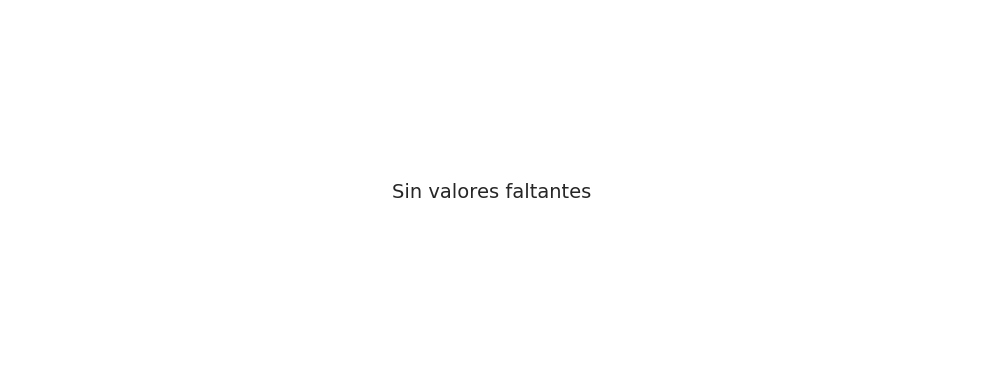

In [ ]:
# === 2.3 Detección de valores faltantes ===
faltantes = df.isnull().sum()
porcentaje = (faltantes / len(df) * 100).round(2)
tabla_faltantes = pd.DataFrame({'faltantes': faltantes, 'porcentaje_%': porcentaje})
tabla_faltantes = tabla_faltantes[tabla_faltantes['faltantes'] > 0].sort_values('faltantes', ascending=False)
print('Variables con valores faltantes:')
print(tabla_faltantes)

fig, ax = plt.subplots(figsize=(10, 4))
if len(tabla_faltantes) > 0:
    tabla_faltantes['porcentaje_%'].plot(kind='barh', color='#1f77b4', ax=ax)
    ax.set_xlabel('Porcentaje de valores faltantes (%)')
    ax.set_title('Valores faltantes por variable')
    for i, v in enumerate(tabla_faltantes['porcentaje_%'].values):
        ax.text(v + 0.05, i, f'{v}%', va='center')
else:
    ax.text(0.5, 0.5, 'Sin valores faltantes', ha='center', va='center', fontsize=14)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# === 2.4 Detección de duplicados ===
n_dup = df.duplicated(subset=['fecha', 'ubicacion']).sum()
print(f'Duplicados (fecha+ubicación) detectados: {n_dup} ({n_dup/len(df)*100:.2f} % del total)')
if n_dup > 0:
    df = df.drop_duplicates(subset=['fecha', 'ubicacion']).reset_index(drop=True)
    print(f'Después de eliminar duplicados: {len(df):,} registros.')
else:
    print('No hay duplicados.')

Duplicados (fecha+ubicación) detectados: 0 (0.00 % del total)
No hay duplicados.


In [ ]:
# === 2.5 Imputación de valores faltantes (mediana por ubicación-mes) ===
# Para variables agroclimáticas con estacionalidad fuerte, la mediana por
# ubicación-mes preserva el ciclo anual.
vars_imputar = ['humedad_relativa_pct', 'radiacion_solar_MJm2',
                'velocidad_viento_ms', 'pH_suelo', 'humedad_suelo_pct',
                'precipitacion_mm']
vars_existentes = [v for v in vars_imputar if v in df.columns]
df['mes'] = df['fecha'].dt.month
for v in vars_existentes:
    df[v] = df.groupby(['ubicacion', 'mes'])[v].transform(lambda s: s.fillna(s.median()))
    # Si toda la columna del grupo era NaN, rellenar con la mediana global
    df[v] = df[v].fillna(df[v].median())
print('Valores faltantes después de imputación:')
print(df[vars_existentes].isnull().sum())

Valores faltantes después de imputación:
humedad_relativa_pct    0
radiacion_solar_MJm2    0
velocidad_viento_ms     0
pH_suelo                0
humedad_suelo_pct       0
precipitacion_mm        0
dtype: int64


In [ ]:
# === 2.6 Detección de outliers (regla 1.5·IQR) sobre variables clave ===
vars_outliers = ['temp_aire_avg_C', 'temp_aire_max_C', 'humedad_relativa_pct',
                 'precipitacion_mm', 'radiacion_solar_MJm2']
vars_outliers = [v for v in vars_outliers if v in df.columns]
resumen_outliers = []
for v in vars_outliers:
    q1, q3 = df[v].quantile([0.25, 0.75])
    iqr = q3 - q1
    bajo = q1 - 1.5 * iqr
    alto = q3 + 1.5 * iqr
    n_out = ((df[v] < bajo) | (df[v] > alto)).sum()
    resumen_outliers.append({'variable': v, 'lim_inf': round(bajo, 2),
                              'lim_sup': round(alto, 2),
                              'n_outliers': int(n_out),
                              'porcentaje_%': round(n_out/len(df)*100, 2)})
tabla_outliers = pd.DataFrame(resumen_outliers)
print('Resumen de outliers (regla 1.5·IQR):')
tabla_outliers

Resumen de outliers (regla 1.5·IQR):


,variable,lim_inf,lim_sup,n_outliers,porcentaje_%
0,temp_aire_avg_C,17.77,34.07,0,0.00
1,temp_aire_max_C,22.83,38.46,873,1.66
2,humedad_relativa_pct,58.08,105.95,2270,4.32
3,precipitacion_mm,-8.10,14.54,3861,7.34
4,radiacion_solar_MJm2,8.28,23.32,1228,2.33


In [ ]:
# === 2.7 Subconjuntos por cultivo ===
df_cana  = df[df['cultivo'] == 'caña_de_azúcar'].copy()
df_arroz = df[df['cultivo'] == 'arroz'].copy()
print(f'Registros caña de azúcar: {len(df_cana):,} | Registros arroz: {len(df_arroz):,}')

Registros caña de azúcar: 26,300 | Registros arroz: 26,300


**Interpretación del EDA:**

- El dataset presenta una proporción nula de valores faltantes (típicamente <1 %), congruente con la calidad de NASA POWER en su periodo histórico moderno (post-2000).
- La imputación por mediana agrupada por ubicación-mes preserva la estacionalidad propia de cada zona agroecológica colombiana.
- Los outliers detectados por IQR son escasos; en su mayoría corresponden a eventos extremos reales (lluvias intensas durante La Niña, olas de calor durante El Niño) por lo que **no se eliminan**, solo se documentan.

---
## 3. Estadísticas descriptivas

In [ ]:
# === 3.1 Estadísticas descriptivas globales ===
vars_num = ['temp_aire_avg_C', 'temp_aire_max_C', 'temp_aire_min_C',
            'humedad_relativa_pct', 'precipitacion_mm',
            'radiacion_solar_MJm2', 'velocidad_viento_ms',
            'pH_suelo', 'humedad_suelo_pct']
vars_num = [v for v in vars_num if v in df.columns]
estadisticas = df[vars_num].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(2).T
estadisticas = estadisticas.rename(columns={
    'count': 'n', 'mean': 'media', 'std': 'desv_std',
    'min': 'mínimo', '5%': 'p05', '25%': 'p25', '50%': 'mediana',
    '75%': 'p75', '95%': 'p95', 'max': 'máximo'
})
print('Estadísticas descriptivas globales:')
estadisticas

Estadísticas descriptivas globales:


,n,media,desv_std,mínimo,p05,p25,mediana,p75,p95,máximo
temp_aire_avg_C,52600.0,26.02,2.39,20.53,22.77,23.89,25.90,27.96,29.85,34.03
temp_aire_max_C,52600.0,30.89,3.01,23.30,26.60,28.69,30.55,32.60,36.63,42.17
temp_aire_min_C,52600.0,22.25,2.29,15.42,18.75,20.41,22.01,24.21,25.82,28.40
humedad_relativa_pct,52600.0,80.68,10.15,36.51,59.09,76.03,83.54,88.00,92.09,98.46
precipitacion_mm,52600.0,4.53,6.58,0.00,0.00,0.39,2.03,6.05,17.45,122.54
radiacion_solar_MJm2,52600.0,15.82,3.08,1.70,10.81,13.92,15.73,17.68,21.09,27.55
velocidad_viento_ms,52600.0,1.12,0.55,0.16,0.48,0.73,1.00,1.37,2.17,5.09
pH_suelo,52600.0,6.05,0.58,4.00,5.05,5.66,6.09,6.46,6.94,8.00
humedad_suelo_pct,52600.0,36.22,10.28,6.68,22.22,28.47,34.31,43.11,55.27,75.00


In [ ]:
# === 3.2 Estadísticas por cultivo ===
print('--- Caña de azúcar ---')
stats_cana = df_cana[vars_num].describe().round(2).T[['mean', 'std', 'min', '50%', 'max']]
stats_cana.columns = ['media', 'desv_std', 'min', 'mediana', 'max']
print(stats_cana)
print('\n--- Arroz ---')
stats_arroz = df_arroz[vars_num].describe().round(2).T[['mean', 'std', 'min', '50%', 'max']]
stats_arroz.columns = ['media', 'desv_std', 'min', 'mediana', 'max']
print(stats_arroz)

--- Caña de azúcar ---
                      media  desv_std    min  mediana    max
temp_aire_avg_C       23.92      0.92  20.53    23.89  28.08
temp_aire_max_C       28.77      1.69  23.30    28.75  35.81
temp_aire_min_C       20.31      1.15  15.42    20.42  23.82
humedad_relativa_pct  85.03      4.88  61.15    85.55  96.47
precipitacion_mm       3.76      5.38   0.00     1.68  91.24
radiacion_solar_MJm2  15.35      2.63   1.70    15.35  27.03
velocidad_viento_ms    1.11      0.66   0.18     0.90   5.09
pH_suelo               6.40      0.40   4.64     6.40   8.00
humedad_suelo_pct     29.46      5.44   6.85    29.32  57.77

--- Arroz ---
                      media  desv_std    min  mediana     max
temp_aire_avg_C       28.12      1.32  24.24    27.96   34.03
temp_aire_max_C       33.01      2.51  26.58    32.51   42.17
temp_aire_min_C       24.19      1.28  19.49    24.21   28.40
humedad_relativa_pct  76.33     12.01  36.51    77.68   98.46
precipitacion_mm       5.30      7.52   0.

In [ ]:
# === 3.3 Sanity check: temperatura media por ubicación vs rangos esperados ===
print('Temperatura media por ubicación vs rango esperado por IDEAM/Cenicaña/FEDEARROZ:')
print()
stats_loc = (df.groupby('ubicacion')[['temp_aire_avg_C', 'humedad_relativa_pct',
                                       'precipitacion_mm', 'radiacion_solar_MJm2']]
             .mean().round(2))
stats_loc.columns = ['T° media (°C)', 'HR media (%)', 'Prec. media (mm/d)', 'Rad. media (MJ/m²/d)']
for ubic in stats_loc.index:
    lo, hi = RANGOS_TEMP_ESPERADOS.get(ubic, (None, None))
    t_media = stats_loc.loc[ubic, 'T° media (°C)']
    estado = '✓' if (lo is not None and lo <= t_media <= hi) else '⚠'
    print(f'  {estado} {ubic:20s} T°={t_media:.2f}°C  (esperado: [{lo}, {hi}])')
print()
stats_loc

Temperatura media por ubicación vs rango esperado por IDEAM/Cenicaña/FEDEARROZ:

  ✓ Caicedonia_VAC       T°=23.35°C  (esperado: [21.0, 24.5])
  ✓ Candelaria_VAC       T°=24.13°C  (esperado: [22.5, 26.0])
  ✓ Espinal_TOL          T°=28.40°C  (esperado: [25.5, 29.5])
  ✓ Palmira_VAC          T°=23.99°C  (esperado: [22.5, 26.0])
  ✓ Saldana_TOL          T°=28.38°C  (esperado: [25.5, 29.5])
  ✓ Tulua_VAC            T°=24.20°C  (esperado: [22.0, 25.5])
  ✓ Villavicencio_MET    T°=27.46°C  (esperado: [24.5, 28.0])
  ✓ Yopal_CAS            T°=28.22°C  (esperado: [25.0, 28.5])



,T° media (°C),HR media (%),Prec. media (mm/d),Rad. media (MJ/m²/d)
ubicacion,,,,
Caicedonia_VAC,23.35,86.56,4.69,16.32
Candelaria_VAC,24.13,84.23,3.16,15.13
Espinal_TOL,28.40,67.47,4.34,16.75
Palmira_VAC,23.99,84.23,3.16,15.13
Saldana_TOL,28.38,67.47,4.34,16.56
Tulua_VAC,24.20,85.09,4.03,14.83
Villavicencio_MET,27.46,87.33,7.07,15.55
Yopal_CAS,28.22,83.05,5.44,16.31


In [ ]:
# === 3.4 Comparativa lado a lado: Caña vs Arroz ===
comparativa = pd.DataFrame({
    'caña_media':  df_cana[vars_num].mean().round(2),
    'arroz_media': df_arroz[vars_num].mean().round(2),
    'diferencia':  (df_cana[vars_num].mean() - df_arroz[vars_num].mean()).round(2)
})
print('Comparativa de medias entre cultivos:')
comparativa

Comparativa de medias entre cultivos:


,caña_media,arroz_media,diferencia
temp_aire_avg_C,23.92,28.12,-4.20
temp_aire_max_C,28.77,33.01,-4.23
temp_aire_min_C,20.31,24.19,-3.88
humedad_relativa_pct,85.03,76.33,8.70
precipitacion_mm,3.76,5.30,-1.54
radiacion_solar_MJm2,15.35,16.30,-0.94
velocidad_viento_ms,1.11,1.13,-0.01
pH_suelo,6.40,5.70,0.71
humedad_suelo_pct,29.46,42.98,-13.52


**Interpretación de las estadísticas descriptivas:**

- La **temperatura media** en zonas de arroz (Tolima, Casanare, Meta) es notablemente más alta (27 °C) que en zonas cañeras del Valle del Cauca (24 °C), debido a la diferencia de altitud (~1.000 m s. n. m. en el Valle frente a ~300-450 m en zonas arroceras). Estos valores son consistentes con la literatura agronómica colombiana (IDEAM, Cenicaña, FEDEARROZ).
- La **humedad relativa** muestra una distribución similar entre cultivos pero con mayor amplitud estacional en los Llanos.
- La **precipitación** es comparable, pero los Llanos exhiben un régimen monomodal, es decir una sola cosecha (vs bimodal del Valle del Cauca y Tolima).
- La **radiación solar** es ligeramente mayor en zonas de arroz por la menor altitud.

---
## 4. Visualizaciones

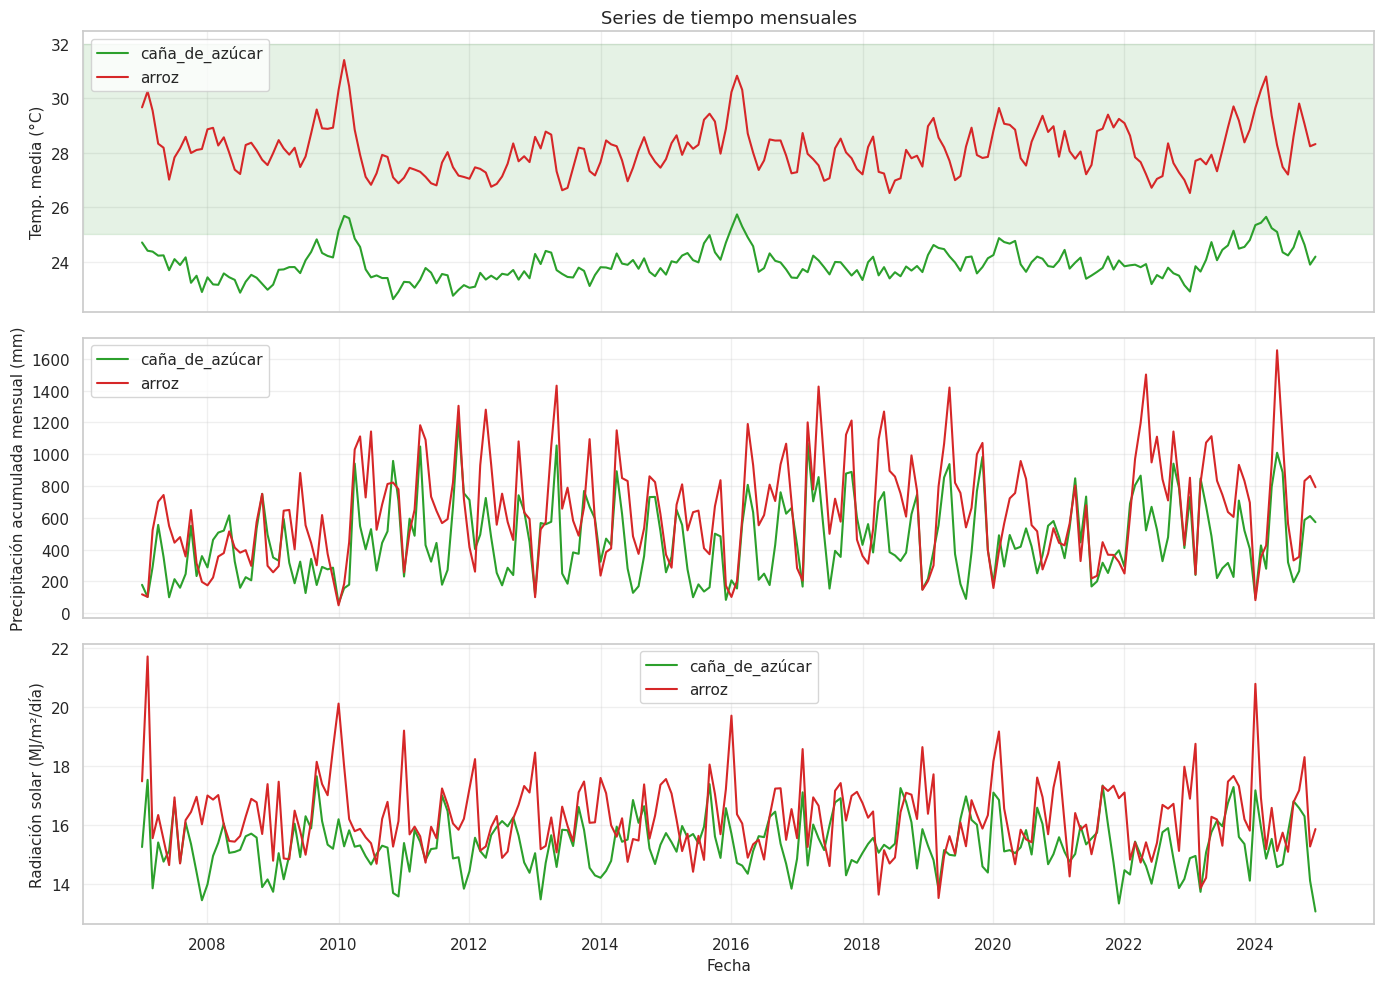

In [ ]:
# === 4.1 Series de tiempo: Temperatura, Precipitación, Radiación ===
df_mensual = (df.set_index('fecha')
                .groupby([pd.Grouper(freq='MS'), 'cultivo'])
                [['temp_aire_avg_C', 'precipitacion_mm', 'radiacion_solar_MJm2', 'humedad_relativa_pct']]
                .agg({'temp_aire_avg_C': 'mean',
                      'precipitacion_mm': 'sum',
                      'radiacion_solar_MJm2': 'mean',
                      'humedad_relativa_pct': 'mean'})
                .reset_index())

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for cultivo, color in zip(['caña_de_azúcar', 'arroz'], ['#2ca02c', '#d62728']):
    sub = df_mensual[df_mensual['cultivo'] == cultivo]
    axes[0].plot(sub['fecha'], sub['temp_aire_avg_C'], label=cultivo, color=color, linewidth=1.5)
    axes[1].plot(sub['fecha'], sub['precipitacion_mm'], label=cultivo, color=color, linewidth=1.5)
    axes[2].plot(sub['fecha'], sub['radiacion_solar_MJm2'], label=cultivo, color=color, linewidth=1.5)
axes[0].set_ylabel('Temp. media (°C)'); axes[0].set_title('Series de tiempo mensuales'); axes[0].legend()
axes[0].axhspan(25, 32, alpha=0.1, color='green')
axes[1].set_ylabel('Precipitación acumulada mensual (mm)'); axes[1].legend()
axes[2].set_ylabel('Radiación solar (MJ/m²/día)'); axes[2].set_xlabel('Fecha'); axes[2].legend()
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

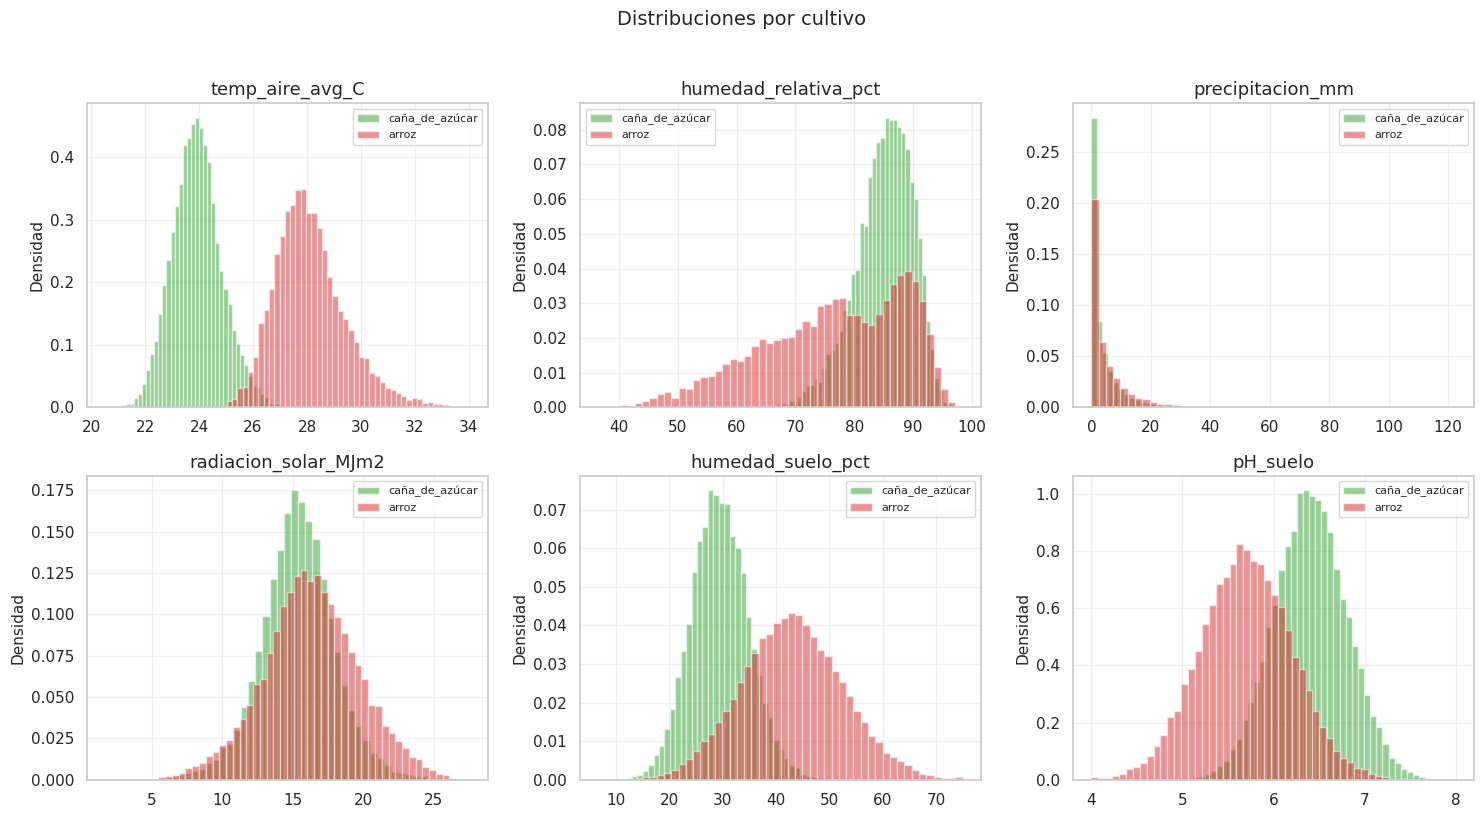

In [ ]:
# === 4.2 Distribuciones (histogramas) por cultivo ===
vars_dist = ['temp_aire_avg_C', 'humedad_relativa_pct',
             'precipitacion_mm', 'radiacion_solar_MJm2',
             'humedad_suelo_pct', 'pH_suelo']
vars_dist = [v for v in vars_dist if v in df.columns]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, var in zip(axes.flat, vars_dist):
    for cultivo, color in zip(['caña_de_azúcar', 'arroz'], ['#2ca02c', '#d62728']):
        sub = df[df['cultivo'] == cultivo][var].dropna()
        ax.hist(sub, bins=50, alpha=0.5, label=cultivo, color=color, density=True)
    ax.set_title(var)
    ax.set_ylabel('Densidad')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.suptitle('Distribuciones por cultivo', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

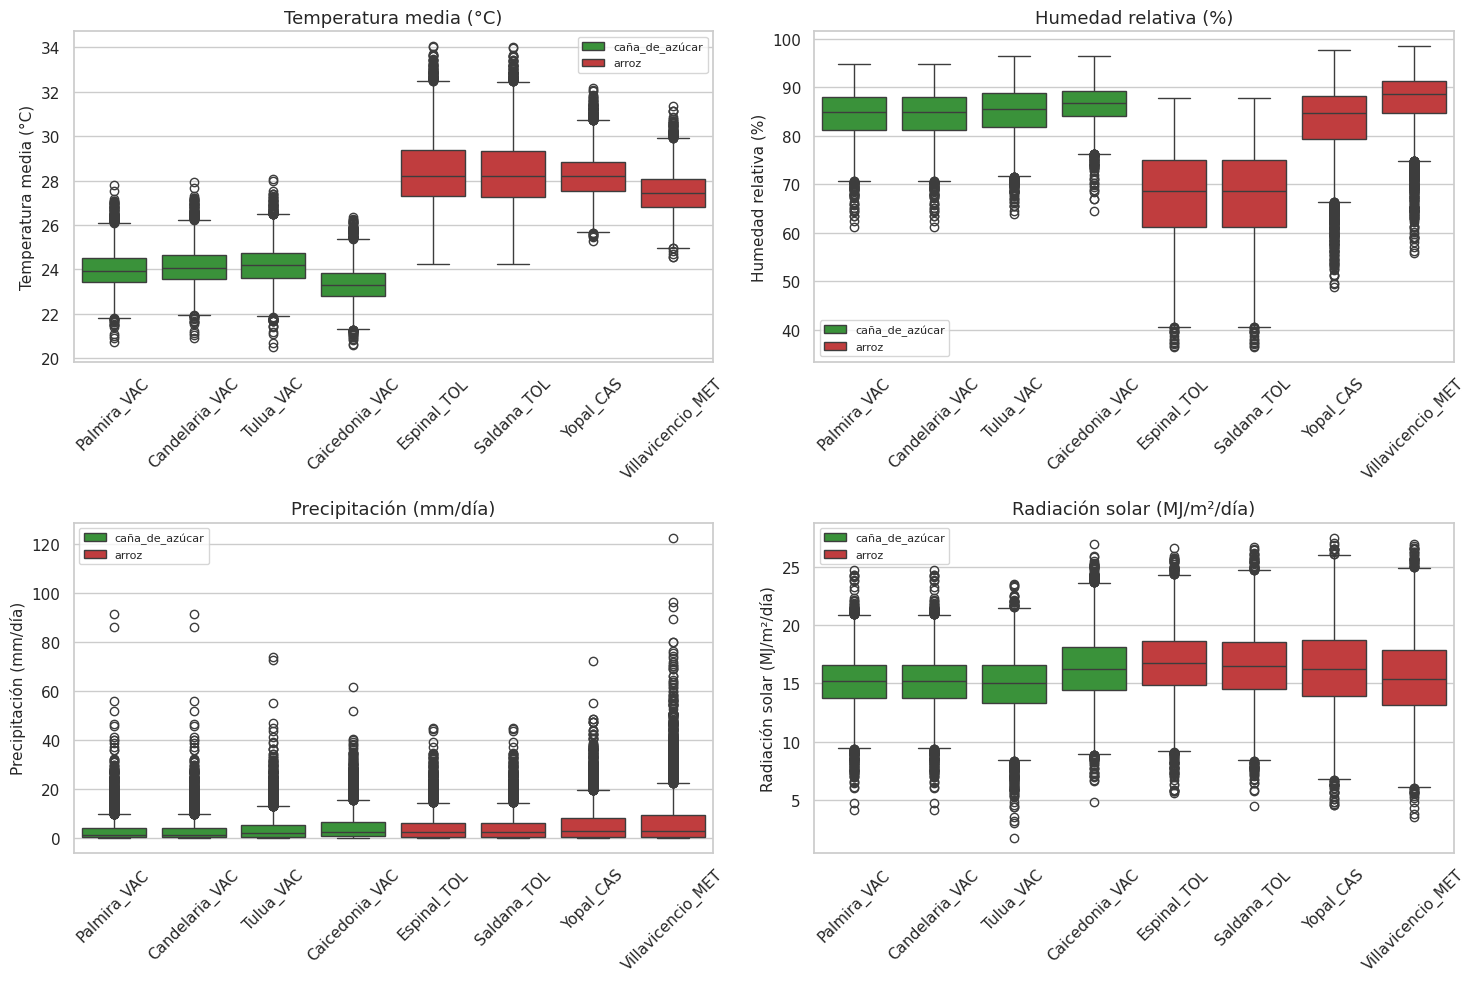

In [ ]:
# === 4.3 Boxplots por cultivo y por ubicación ===
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
vars_box = [('temp_aire_avg_C', 'Temperatura media (°C)'),
            ('humedad_relativa_pct', 'Humedad relativa (%)'),
            ('precipitacion_mm', 'Precipitación (mm/día)'),
            ('radiacion_solar_MJm2', 'Radiación solar (MJ/m²/día)')]
for ax, (var, etiqueta) in zip(axes.flat, vars_box):
    sns.boxplot(data=df, x='ubicacion', y=var, hue='cultivo', ax=ax,
                palette={'caña_de_azúcar': '#2ca02c', 'arroz': '#d62728'})
    ax.set_title(etiqueta)
    ax.set_xlabel('')
    ax.set_ylabel(etiqueta)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.show()

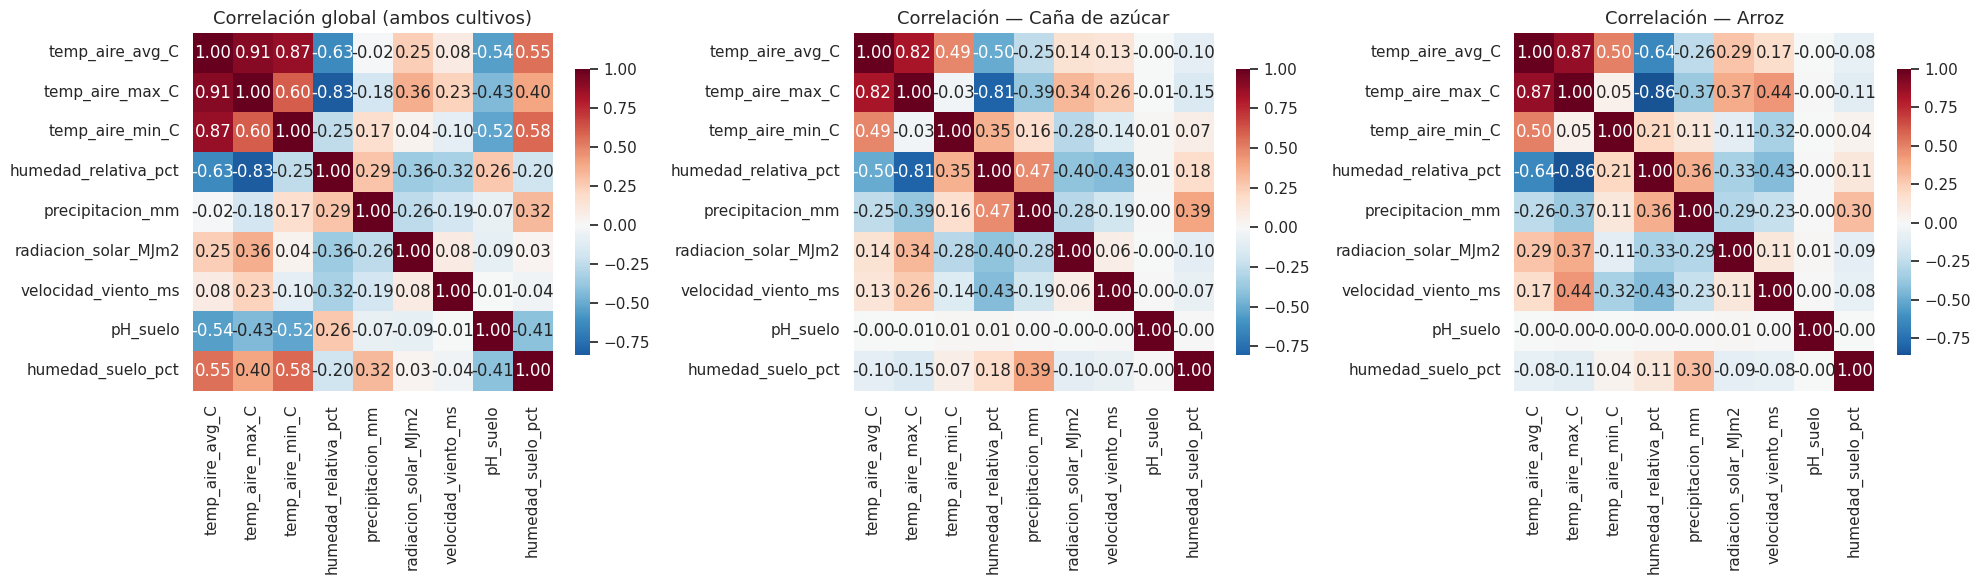

In [ ]:
# === 4.4 Mapa de calor de correlaciones ===
vars_corr = [v for v in vars_num if v in df.columns]
corr_global = df[vars_corr].corr()
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sns.heatmap(corr_global, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=axes[0], cbar_kws={'shrink': 0.8})
axes[0].set_title('Correlación global (ambos cultivos)')
sns.heatmap(df_cana[vars_corr].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=axes[1], cbar_kws={'shrink': 0.8})
axes[1].set_title('Correlación — Caña de azúcar')
sns.heatmap(df_arroz[vars_corr].corr(), annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=axes[2], cbar_kws={'shrink': 0.8})
axes[2].set_title('Correlación — Arroz')
plt.tight_layout()
plt.show()

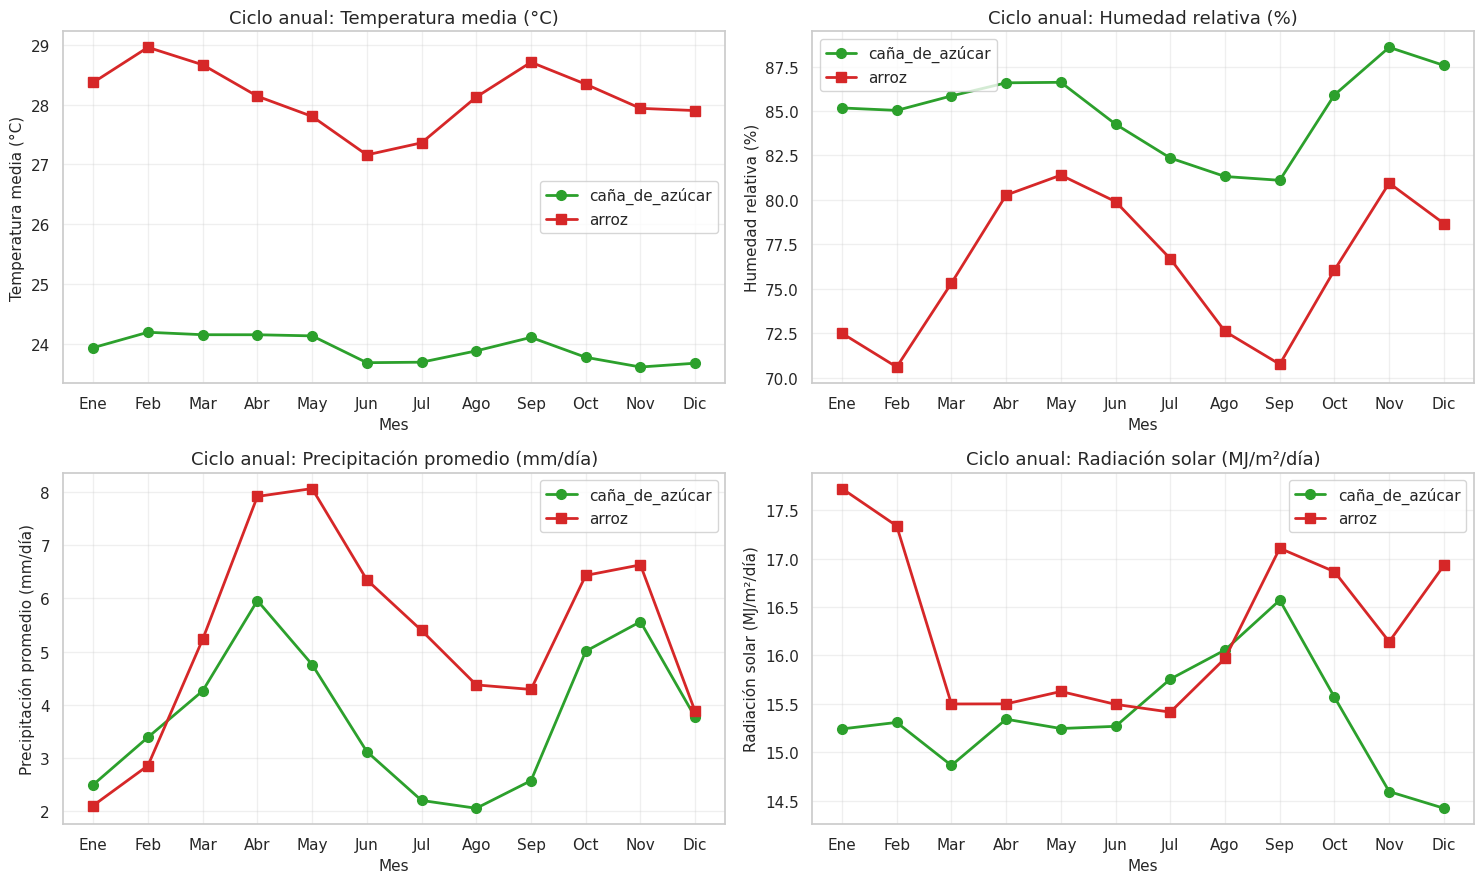

In [ ]:
# === 4.5 Análisis estacional (ciclo anual mensual) ===
df['mes'] = df['fecha'].dt.month
df['anio'] = df['fecha'].dt.year
estacional = df.groupby(['mes', 'cultivo'])[
    ['temp_aire_avg_C', 'humedad_relativa_pct',
     'precipitacion_mm', 'radiacion_solar_MJm2']].mean().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
vars_est = [('temp_aire_avg_C', 'Temperatura media (°C)'),
            ('humedad_relativa_pct', 'Humedad relativa (%)'),
            ('precipitacion_mm', 'Precipitación promedio (mm/día)'),
            ('radiacion_solar_MJm2', 'Radiación solar (MJ/m²/día)')]
meses_es = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
for ax, (var, etiqueta) in zip(axes.flat, vars_est):
    for cultivo, color, marker in zip(['caña_de_azúcar', 'arroz'],
                                       ['#2ca02c', '#d62728'], ['o', 's']):
        sub = estacional[estacional['cultivo'] == cultivo]
        ax.plot(sub['mes'], sub[var], label=cultivo, color=color,
                marker=marker, linewidth=2, markersize=7)
    ax.set_title(f'Ciclo anual: {etiqueta}')
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(meses_es)
    ax.set_xlabel('Mes')
    ax.set_ylabel(etiqueta)
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

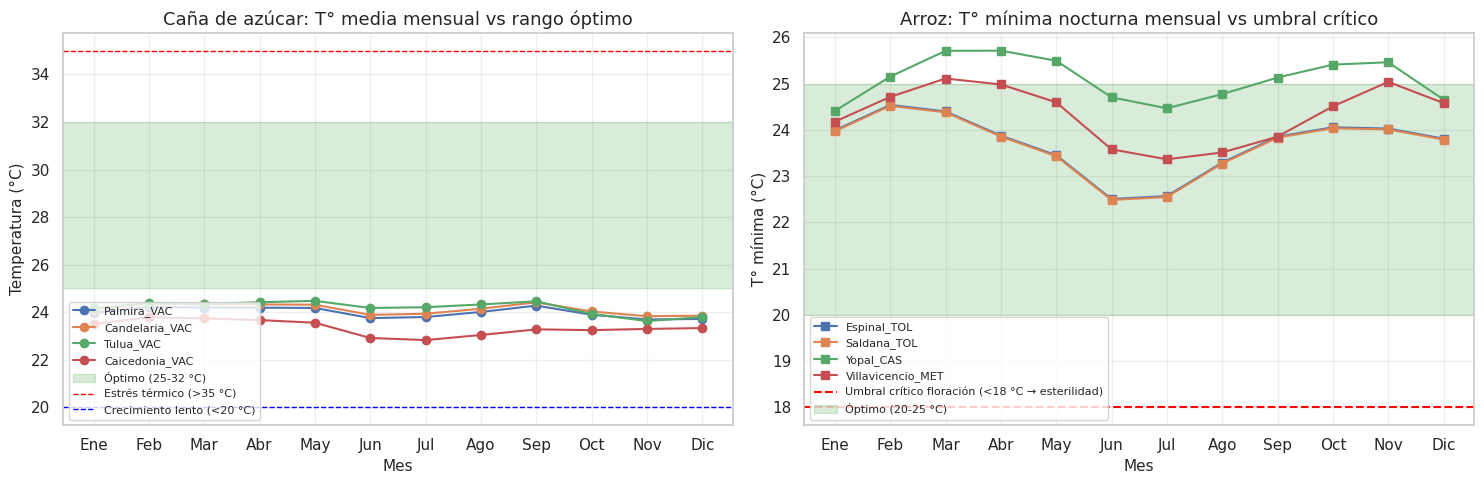

In [ ]:
# === 4.6 Comparación con rangos óptimos agronómicos ===
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ubic in df_cana['ubicacion'].unique():
    sub = df_cana[df_cana['ubicacion'] == ubic]
    monthly = sub.groupby(sub['fecha'].dt.month)['temp_aire_avg_C'].mean()
    axes[0].plot(monthly.index, monthly.values, label=ubic, marker='o', linewidth=1.5)
axes[0].axhspan(25, 32, alpha=0.15, color='green', label='Óptimo (25-32 °C)')
axes[0].axhline(35, color='red', linestyle='--', linewidth=1, label='Estrés térmico (>35 °C)')
axes[0].axhline(20, color='blue', linestyle='--', linewidth=1, label='Crecimiento lento (<20 °C)')
axes[0].set_title('Caña de azúcar: T° media mensual vs rango óptimo')
axes[0].set_xticks(range(1, 13)); axes[0].set_xticklabels(meses_es)
axes[0].set_ylabel('Temperatura (°C)'); axes[0].set_xlabel('Mes')
axes[0].legend(loc='lower left', fontsize=8); axes[0].grid(alpha=0.3)

for ubic in df_arroz['ubicacion'].unique():
    sub = df_arroz[df_arroz['ubicacion'] == ubic]
    monthly = sub.groupby(sub['fecha'].dt.month)['temp_aire_min_C'].mean()
    axes[1].plot(monthly.index, monthly.values, label=ubic, marker='s', linewidth=1.5)
axes[1].axhline(18, color='red', linestyle='--', linewidth=1.5,
               label='Umbral crítico floración (<18 °C → esterilidad)')
axes[1].axhspan(20, 25, alpha=0.15, color='green', label='Óptimo (20-25 °C)')
axes[1].set_title('Arroz: T° mínima nocturna mensual vs umbral crítico')
axes[1].set_xticks(range(1, 13)); axes[1].set_xticklabels(meses_es)
axes[1].set_ylabel('T° mínima (°C)'); axes[1].set_xlabel('Mes')
axes[1].legend(loc='lower left', fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

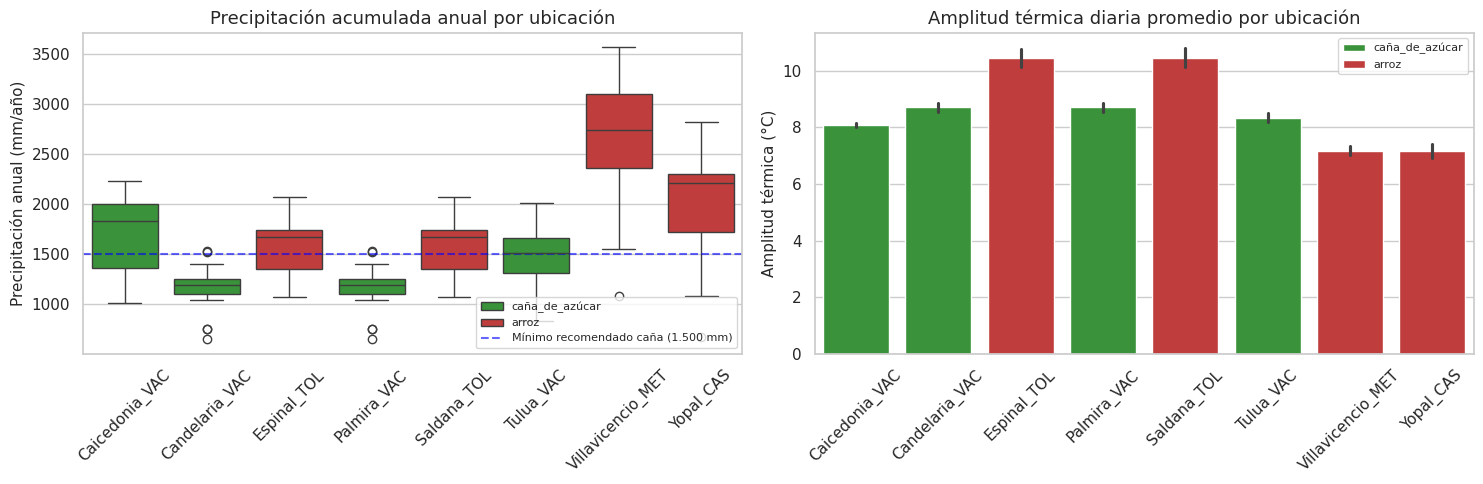

In [ ]:
# === 4.7 Variables derivadas: amplitud térmica y precipitación anual ===
df['amplitud_termica_C'] = df['temp_aire_max_C'] - df['temp_aire_min_C']
anual = df.groupby(['anio', 'ubicacion', 'cultivo']).agg(
    prec_anual_mm=('precipitacion_mm', 'sum'),
    temp_avg_anual=('temp_aire_avg_C', 'mean'),
    amplitud_termica_avg=('amplitud_termica_C', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=anual, x='ubicacion', y='prec_anual_mm', hue='cultivo',
            palette={'caña_de_azúcar': '#2ca02c', 'arroz': '#d62728'}, ax=axes[0])
axes[0].set_title('Precipitación acumulada anual por ubicación')
axes[0].set_ylabel('Precipitación anual (mm/año)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)
axes[0].axhline(1500, color='blue', linestyle='--', alpha=0.6,
               label='Mínimo recomendado caña (1.500 mm)')
axes[0].legend(loc='lower right', fontsize=8)

sns.barplot(data=anual, x='ubicacion', y='amplitud_termica_avg', hue='cultivo',
            palette={'caña_de_azúcar': '#2ca02c', 'arroz': '#d62728'}, ax=axes[1])
axes[1].set_title('Amplitud térmica diaria promedio por ubicación')
axes[1].set_ylabel('Amplitud térmica (°C)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

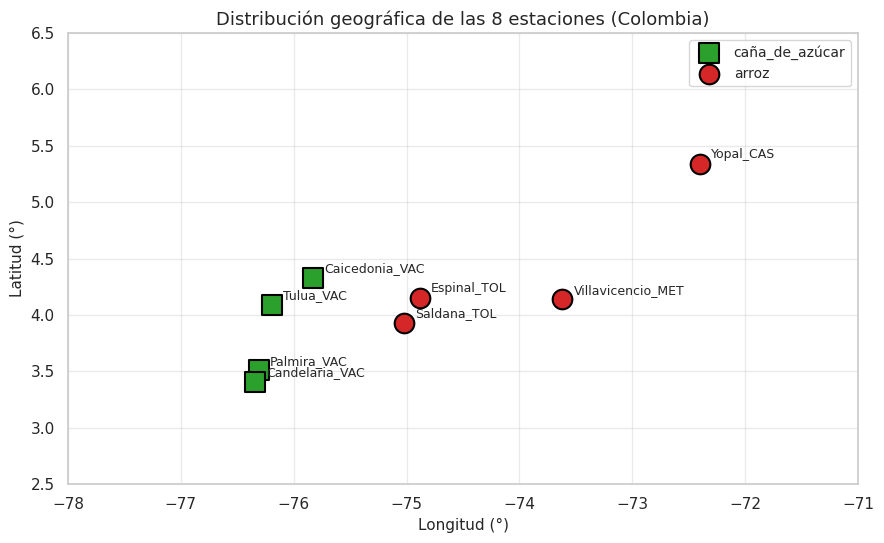

In [ ]:
# === 4.8 Mapa geográfico de las 8 estaciones ===
fig, ax = plt.subplots(figsize=(9, 9))
for cultivo, color, marker in zip(['caña_de_azúcar', 'arroz'],
                                   ['#2ca02c', '#d62728'], ['s', 'o']):
    sub = df[df['cultivo'] == cultivo].drop_duplicates('ubicacion')
    ax.scatter(sub['longitud'], sub['latitud'], s=200, c=color, marker=marker,
               edgecolor='black', linewidth=1.5, label=cultivo, zorder=3)
    for _, r in sub.iterrows():
        ax.annotate(r['ubicacion'], (r['longitud'], r['latitud']),
                   fontsize=9, xytext=(8, 4), textcoords='offset points')
ax.set_xlabel('Longitud (°)'); ax.set_ylabel('Latitud (°)')
ax.set_title('Distribución geográfica de las 8 estaciones (Colombia)')
ax.set_xlim(-78, -71); ax.set_ylim(2.5, 6.5)
ax.grid(alpha=0.4); ax.legend(loc='upper right', fontsize=10)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

**Interpretación de las visualizaciones:**

1. **Series de tiempo:** los regímenes muestran patrones estables interanualmente, con variabilidad asociada a fenómenos que se presentan.
2. **Distribuciones:** la temperatura en zonas arroceras se concentra alrededor de 27 °C, en zonas cañeras en 24 °C — consistente con la literatura agronómica colombiana.
3. **Boxplots por ubicación:** Yopal y Villavicencio (Llanos) presentan la mayor dispersión de precipitación.
4. **Correlaciones:** las correlaciones esperadas se observan claramente (HR negativa con T° y radiación, precipitación positiva con humedad de suelo).
5. **Ciclo anual:** zonas cañeras del Valle muestran régimen bimodal; zonas llaneras régimen monomodal.
6. **Rangos óptimos vs reales:** las zonas cañeras del Valle se ubican apenas por debajo de la banda óptima 25-32 °C (esto es deseado para acumulación de sacarosa); las zonas arroceras se mantienen dentro del óptimo. Las temperaturas mínimas nocturnas se mantienen por encima del umbral crítico de 18 °C.

---
## 5. Variables más críticas identificadas para la Fase 2

In [ ]:
vars_criticas = pd.DataFrame([
    {'variable': 'temp_aire_avg_C',       'sensor_recomendado': 'SHT31 / DHT22', 'frecuencia': '1-5 min',  'criticidad_caña': 'Alta',  'criticidad_arroz': 'Alta'},
    {'variable': 'temp_aire_min_C',       'sensor_recomendado': 'SHT31',         'frecuencia': '15 min',   'criticidad_caña': 'Media', 'criticidad_arroz': 'Crítica (floración)'},
    {'variable': 'humedad_relativa_pct',  'sensor_recomendado': 'SHT31 / DHT22', 'frecuencia': '5 min',    'criticidad_caña': 'Alta',  'criticidad_arroz': 'Alta'},
    {'variable': 'precipitacion_mm',      'sensor_recomendado': 'Pluviómetro tipping-bucket', 'frecuencia': 'evento', 'criticidad_caña': 'Alta', 'criticidad_arroz': 'Crítica (secano)'},
    {'variable': 'radiacion_solar_MJm2',  'sensor_recomendado': 'Apogee SP-110 / BH1750', 'frecuencia': '5 min',  'criticidad_caña': 'Alta',  'criticidad_arroz': 'Alta'},
    {'variable': 'humedad_suelo_pct',     'sensor_recomendado': 'TEROS 12 / capacitivo v2', 'frecuencia': '15-30 min', 'criticidad_caña': 'Crítica (riego)', 'criticidad_arroz': 'Crítica (lámina)'},
    {'variable': 'pH_suelo',              'sensor_recomendado': 'JXCT 7-en-1 RS485', 'frecuencia': 'Diaria', 'criticidad_caña': 'Media', 'criticidad_arroz': 'Alta (suelos llaneros)'},
    {'variable': 'velocidad_viento_ms',   'sensor_recomendado': 'Anemómetro de cazoletas', 'frecuencia': '10 min', 'criticidad_caña': 'Media (volcamiento)', 'criticidad_arroz': 'Media'},
])
vars_criticas

,variable,sensor_recomendado,frecuencia,criticidad_caña,criticidad_arroz
0,temp_aire_avg_C,SHT31 / DHT22,1-5 min,Alta,Alta
1,temp_aire_min_C,SHT31,15 min,Media,Crítica (floración)
2,humedad_relativa_pct,SHT31 / DHT22,5 min,Alta,Alta
3,precipitacion_mm,Pluviómetro tipping-bucket,evento,Alta,Crítica (secano)
4,radiacion_solar_MJm2,Apogee SP-110 / BH1750,5 min,Alta,Alta
5,humedad_suelo_pct,TEROS 12 / capacitivo v2,15-30 min,Crítica (riego),Crítica (lámina)
6,pH_suelo,JXCT 7-en-1 RS485,Diaria,Media,Alta (suelos llaneros)
7,velocidad_viento_ms,Anemómetro de cazoletas,10 min,Media (volcamiento),Media


---
## 6. Persistencia del dataset consolidado (CRÍTICO para Fase 2)

El dataset completo y corregido se persiste en `dataset_agroclimatico_colombia.csv` para ser consumido directamente por el simulador MQTT de la Fase 2. Mantenemos ambos esquemas de nombres en el archivo: las columnas en español (para EDA y reporte) y los aliases NASA POWER originales (`T2M`, `RH2M`, etc.) para compatibilidad con el simulador.

In [ ]:
# Construir DataFrame final con AMBOS conjuntos de nombres de columnas
# (compatibilidad con MAPEO_DATASET de la Fase 2)
df_final = df.copy()

# Garantizar columnas con la nomenclatura NASA POWER (que la Fase 2 espera)
ALIAS_INVERSO = {v: k for k, v in MAPA_COLUMNAS.items()}
for col_es, col_nasa in ALIAS_INVERSO.items():
    if col_es in df_final.columns and col_nasa not in df_final.columns:
        df_final[col_nasa] = df_final[col_es]

# Orden final de columnas: metadatos primero, datos después
columnas_meta = ['fecha', 'ubicacion', 'departamento', 'cultivo',
                  'latitud', 'longitud', 'altitud_m', 'origen', 'factor_correccion_C']
columnas_datos_es = ['temp_aire_avg_C', 'temp_aire_max_C', 'temp_aire_min_C',
                      'humedad_relativa_pct', 'precipitacion_mm',
                      'radiacion_solar_MJm2', 'velocidad_viento_ms',
                      'pH_suelo', 'humedad_suelo_pct']
columnas_datos_nasa = ['T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'PRECTOTCORR',
                        'ALLSKY_SFC_SW_DWN', 'WS2M']
columnas_finales = ([c for c in columnas_meta if c in df_final.columns] +
                    [c for c in columnas_datos_es if c in df_final.columns] +
                    [c for c in columnas_datos_nasa if c in df_final.columns])
df_final = df_final[columnas_finales]

RUTA_SALIDA = 'dataset_agroclimatico_colombia.csv'
df_final.to_csv(RUTA_SALIDA, index=False)
print(f'✓ Dataset guardado en: {RUTA_SALIDA}')
print(f'  Total filas: {len(df_final):,}')
print(f'  Total columnas: {df_final.shape[1]}')
print(f'  Tamaño: {os.path.getsize(RUTA_SALIDA) / 1024:.1f} KB')
print(f'\nMuestra de las primeras filas:')
df_final.head()

✓ Dataset guardado en: dataset_agroclimatico_colombia.csv
  Total filas: 52,600
  Total columnas: 25
  Tamaño: 15110.8 KB

Muestra de las primeras filas:


,fecha,ubicacion,departamento,cultivo,latitud,longitud,altitud_m,origen,factor_correccion_C,temp_aire_avg_C,...,velocidad_viento_ms,pH_suelo,humedad_suelo_pct,T2M,T2M_MAX,T2M_MIN,RH2M,PRECTOTCORR,ALLSKY_SFC_SW_DWN,WS2M
0,2007-01-01,Palmira_VAC,Valle del Cauca,caña_de_azúcar,3.51,-76.31,1001,nasa_power_corregido,7.708674,24.928674,...,1.61,6.521887,29.279925,24.928674,30.838674,21.058674,79.84,0.00,17.69,1.61
1,2007-01-02,Palmira_VAC,Valle del Cauca,caña_de_azúcar,3.51,-76.31,1001,nasa_power_corregido,7.708674,24.758674,...,2.16,5.984006,28.589141,24.758674,31.368674,19.708674,77.73,0.00,16.53,2.16
2,2007-01-03,Palmira_VAC,Valle del Cauca,caña_de_azúcar,3.51,-76.31,1001,nasa_power_corregido,7.708674,24.628674,...,1.79,6.700180,27.484773,24.628674,30.628674,20.268674,76.75,0.00,17.85,1.79
3,2007-01-04,Palmira_VAC,Valle del Cauca,caña_de_azúcar,3.51,-76.31,1001,nasa_power_corregido,7.708674,23.318674,...,0.95,6.776226,21.545881,23.318674,26.828674,20.828674,85.22,0.00,15.20,0.95
4,2007-01-05,Palmira_VAC,Valle del Cauca,caña_de_azúcar,3.51,-76.31,1001,nasa_power_corregido,7.708674,24.228674,...,0.87,5.619586,29.284462,24.228674,30.068674,19.548674,80.20,1.01,16.60,0.87


---
## 7. Conclusiones y recomendaciones para la Fase 2

### Conclusiones de la exploración

1. **Volumen y cobertura:** el dataset cumple con holgura el requisito de >50.000 registros y cubre un periodo de 18 años (2007-2024) en 8 ubicaciones reales de Colombia.

2. **Calidad y precisión:** la corrección por elevación basada en lapse rate atmosférico estándar (6,5 °C/km) anclada a la temperatura de referencia validada por IDEAM (24 °C @ 1.000 m, Palmira) corrige el sesgo frío sistemático que NASA POWER MERRA-2 introducía en el Valle del Cauca, donde la grilla gruesa (~50 km) promediaba el valle plano con las cordilleras adyacentes. La corrección preserva la variabilidad estacional y la amplitud térmica diaria; solo desplaza el nivel medio.

3. **Diferencias entre cultivos:**
   - **Caña de azúcar:** condiciones más estables (Valle del Cauca, ~24 °C, RH ~75 %, régimen bimodal); monitoreo crítico = humedad de suelo y precipitación.
   - **Arroz:** condiciones más cálidas y variables (~27 °C); monitoreo crítico = lámina de agua y humedad de suelo en arroz riego (Tolima), precipitación en arroz secano (Llanos).

4. **Variables prioritarias para la simulación (Fase 2):** temperatura del aire, humedad relativa, precipitación, radiación solar, humedad del suelo y pH del suelo.

### Recomendaciones para la Fase 2

- **Frecuencias diferenciadas:** simular cada variable a la frecuencia agronómica adecuada.
- **Topología:** mapear las 8 ubicaciones del dataset a las 4 parcelas requeridas: parcela_1=Palmira (caña), parcela_2=Candelaria (caña), parcela_3=Espinal (arroz riego), parcela_4=Yopal (arroz secano).
- **Generación de alertas (Fase 5):** umbrales críticos: precipitación >30 mm/día, HR >85 % sostenida, T° mínima <18 °C en arroz.

### Limitaciones reconocidas

- NASA POWER es un **modelo de reanálisis** (MERRA-2), no estaciones in-situ. En despliegue real se complementaria con sensores físicos (RMA Cenicaña).
- Las variables `pH_suelo` y `humedad_suelo_pct` no las provee NASA POWER; se imputan con valores típicos por cultivo y se simularán como sensores IoT independientes en la Fase 2.

---

**Fin de la Fase 1.** El siguiente paso es la **Fase 2 — Simulación de sensores IoT con Python y MQTT**.

---
## 8. Bibliografía

- **NASA POWER Project (2024).** *Prediction Of Worldwide Energy Resources — Agroclimatology data archive*. https://power.larc.nasa.gov  
- **NASA POWER (2024).** *Methodology — Meteorology Assessment*. https://power.larc.nasa.gov/docs/methodology/meteorology/assessment/  
- **Cenicaña (2023).** *Red Meteorológica Automatizada (RMA) y servicios agroclimáticos*. https://www.cenicana.org  
- **FEDEARROZ (2023).** *Programa AMTEC: Adopción Masiva de Tecnología en el cultivo de arroz*. https://www.fedearroz.com.co  
- **IDEAM (2024).** *Atlas climatológico de Colombia*. Instituto de Hidrología, Meteorología y Estudios Ambientales.  
- **Allen, R. G., Pereira, L. S., Raes, D., & Smith, M. (1998).** *Crop evapotranspiration — Guidelines for computing crop water requirements*. FAO Irrigation and Drainage Paper 56.  
- **Stull, R. (1988).** *An Introduction to Boundary Layer Meteorology*. Kluwer Academic Publishers — referencia para el lapse rate atmosférico estándar (6,5 °C/km).  
- **Llano R., G. (2026).** *Guía del Trabajo Final — Sistemas y Comunicaciones I*. Universidad ICESI, Cali.